In [1]:
!pip install -q xgboost catboost shap joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

RANDOM_STATE = 42

In [3]:
from google.colab import files

uploaded = files.upload()

Saving River Water Quality Monitoring Data.csv to River Water Quality Monitoring Data.csv


In [4]:
df = pd.read_csv(
    "River Water Quality Monitoring Data.csv",
    low_memory=False
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (29997, 16)


,siteid,siteengname,countyen,townshipen,basinen,riveren,twd97lon,twd97lat,twd97tm2x,twd97tm2y,sampledate,itemengname,itemengabbreviation,itemvalue,itemunit,noteen
0,1001,Jhongshou Bridge.,Taipei City,Zhongzheng District,Danshuei River,Danshuei River,121.500209,25.051144,300470.59,2771535.67,2025-10-09 06:36:48,River Pollution Index,RPI,6.25,NaN,NaN
1,1001,Jhongshou Bridge.,Taipei City,Zhongzheng District,Danshuei River,Danshuei River,121.500209,25.051144,300470.59,2771535.67,2025-10-09 06:36:48,Water Temperature,WT,28.4,℃,NaN
2,1001,Jhongshou Bridge.,Taipei City,Zhongzheng District,Danshuei River,Danshuei River,121.500209,25.051144,300470.59,2771535.67,2025-10-09 06:36:48,pH,pH,7.48,,NaN
3,1001,Jhongshou Bridge.,Taipei City,Zhongzheng District,Danshuei River,Danshuei River,121.500209,25.051144,300470.59,2771535.67,2025-10-09 06:36:48,Turbidity,TB,-,NTU,NaN
4,1001,Jhongshou Bridge.,Taipei City,Zhongzheng District,Danshuei River,Danshuei River,121.500209,25.051144,300470.59,2771535.67,2025-10-09 06:36:48,Conductivity,EC,2920,μmho/cm25℃,NaN


In [5]:
print("Columns:")

for col in df.columns:
    print(col)

Columns:
siteid
siteengname
countyen
townshipen
basinen
riveren
twd97lon
twd97lat
twd97tm2x
twd97tm2y
sampledate
itemengname
itemengabbreviation
itemvalue
itemunit
noteen


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29997 entries, 0 to 29996
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   siteid               29997 non-null  int64  
 1   siteengname          29997 non-null  object 
 2   countyen             29997 non-null  object 
 3   townshipen           29997 non-null  object 
 4   basinen              29997 non-null  object 
 5   riveren              29997 non-null  object 
 6   twd97lon             29997 non-null  float64
 7   twd97lat             29997 non-null  float64
 8   twd97tm2x            29997 non-null  float64
 9   twd97tm2y            29997 non-null  float64
 10  sampledate           29997 non-null  object 
 11  itemengname          29997 non-null  object 
 12  itemengabbreviation  29997 non-null  object 
 13  itemvalue            29997 non-null  object 
 14  itemunit             29088 non-null  object 
 15  noteen               0 non-null     

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
siteid,29997.0,NaN,NaN,NaN,1216.928493,183.763497,1001.0,1088.0,1179.0,1262.0,1724.0
siteengname,29997,294,Jhongjheng Bridge,495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
countyen,29997,19,Tainan City,3069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
townshipen,29997,174,Sinfong Township,594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basinen,29997,54,Danshuei River,3762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
riveren,29997,87,Keelung River,1287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
twd97lon,29997.0,NaN,NaN,NaN,120.955204,0.494943,120.06263,120.535778,120.917134,121.373777,121.909529
twd97lat,29997.0,NaN,NaN,NaN,24.025674,0.885493,21.988222,23.253528,24.177102,24.852576,25.227357
twd97tm2x,29997.0,NaN,NaN,NaN,245207.831409,50365.474899,153936.59,202375.668792,241617.32,287761.02,341794.94
twd97tm2y,29997.0,NaN,NaN,NaN,2657960.880212,98054.549086,2432276.26,2572581.08,2674687.15,2749448.78,2791109.59


In [8]:
df["itemvalue_numeric"] = (
    df["itemvalue"]
    .astype(str)
    .str.strip()
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
)

df["itemvalue_numeric"] = pd.to_numeric(
    df["itemvalue_numeric"],
    errors="coerce"
)

print(
    df["itemvalue_numeric"].describe()
)

count    1.753000e+04
mean     7.552238e+03
std      3.719761e+05
min      3.000000e-04
25%      5.000000e-03
50%      2.000000e+00
75%      2.037500e+01
max      4.800000e+07
Name: itemvalue_numeric, dtype: float64


In [9]:
df["sampledate"] = pd.to_datetime(
    df["sampledate"],
    errors="coerce"
)

print("Earliest sample:")
print(df["sampledate"].min())

print("\nLatest sample:")
print(df["sampledate"].max())

Earliest sample:
2021-01-04 07:27:17

Latest sample:
2026-07-27 15:30:00


In [10]:
missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(
        ascending=False
    )
)

noteen               29997
itemvalue_numeric    12467
itemunit               909
dtype: int64


In [11]:
print(
    "Duplicate raw rows:",
    df.duplicated().sum()
)

Duplicate raw rows: 0


In [12]:
parameters = (
    df["itemengname"]
    .dropna()
    .unique()
)

print(
    "Number of parameters:",
    len(parameters)
)

for parameter in parameters:
    print(parameter)

Number of parameters: 32
River Pollution Index
Water Temperature
pH
Turbidity
Conductivity
Temperature
Suspended Solid
Dissolved Oxygen
Biochemical Oxygen Demand
Chemical Oxygen Demand
Total Organic Carbon
NH3-N
TKN
Nitrate-Nitrogen
Nitrite-Nitrogen
Total Nitrogen
Chloride
Dissolved Oxygen Saturation
Total-Phosphate
Coliform Group
Manganese
Zinc
Copper
Nickel
Chromium
Lead
Arsenic
Cadmium
Selenium
Silver
Hexavalent Chromium
Mercury


In [13]:
quality_df = df.pivot_table(
    index=[
        "siteid",
        "siteengname",
        "countyen",
        "townshipen",
        "basinen",
        "riveren",
        "twd97lon",
        "twd97lat",
        "sampledate"
    ],
    columns="itemengname",
    values="itemvalue_numeric",
    aggfunc="mean"
).reset_index()

quality_df.columns.name = None

print(
    "Model-ready shape:",
    quality_df.shape
)

quality_df.head()

Model-ready shape: (861, 37)


,siteid,siteengname,countyen,townshipen,basinen,riveren,twd97lon,twd97lat,sampledate,Arsenic,...,River Pollution Index,Selenium,Silver,Suspended Solid,Temperature,Total Organic Carbon,Total-Phosphate,Water Temperature,Zinc,pH
0,1001,Jhongshou Bridge.,New Taipei City,Zhongzheng District,Danshuei River,Danshuei River,121.500209,25.051144,2021-01-07 11:51:29,0.0005,...,3.25,0.001,0.001,17.1,12.4,1.70,0.382,17.2,0.017,7.44
1,1001,Jhongshou Bridge.,Taipei City,Zhongzheng District,Danshuei River,Danshuei River,121.500209,25.051144,2025-10-09 06:36:48,NaN,...,6.25,NaN,NaN,74.7,27.3,NaN,NaN,28.4,NaN,7.48
2,1001,Jhongshou Bridge.,Taipei City,Zhongzheng District,Danshuei River,Danshuei River,121.500209,25.051144,2026-07-07 10:25:00,0.0009,...,2.50,NaN,0.001,28.7,32.4,NaN,0.130,26.4,0.016,7.42
3,1002,Chongyang Bridge,Taipei City,Shihlin District,Danshuei River,Danshuei River,121.502797,25.084174,2021-01-07 11:26:00,0.0007,...,3.50,0.001,0.001,15.0,12.3,1.52,0.288,17.1,0.012,7.32
4,1002,Chongyang Bridge,Taipei City,Shihlin District,Danshuei River,Danshuei River,121.502797,25.084174,2025-10-09 06:12:14,NaN,...,5.75,NaN,NaN,87.4,27.5,NaN,NaN,28.6,NaN,7.32


In [14]:
# ============================================================
# CELL 14 — INSPECT MODEL-READY DATA
# ============================================================

print("MODEL-READY SHAPE")
print("=================")
print(quality_df.shape)

print("\nCOLUMN NAMES")
print("============")

for i, col in enumerate(quality_df.columns, 1):
    print(f"{i:2}. {col}")

TARGET = "River Pollution Index"

print("\nTARGET")
print("======")
print(TARGET)

print("\nTARGET STATISTICS")
print("=================")
print(quality_df[TARGET].describe())

print("\nMISSING VALUES")
print("==============")

missing = quality_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

print("\nDUPLICATE ROWS")
print("==============")
print(quality_df.duplicated().sum())

MODEL-READY SHAPE
(861, 37)

COLUMN NAMES
 1. siteid
 2. siteengname
 3. countyen
 4. townshipen
 5. basinen
 6. riveren
 7. twd97lon
 8. twd97lat
 9. sampledate
10. Arsenic
11. Biochemical Oxygen Demand
12. Cadmium
13. Chemical Oxygen Demand
14. Chloride
15. Coliform Group
16. Conductivity
17. Copper
18. Dissolved Oxygen
19. Dissolved Oxygen Saturation
20. Hexavalent Chromium
21. Lead
22. Manganese
23. Mercury
24. NH3-N
25. Nickel
26. Nitrate-Nitrogen
27. Nitrite-Nitrogen
28. River Pollution Index
29. Selenium
30. Silver
31. Suspended Solid
32. Temperature
33. Total Organic Carbon
34. Total-Phosphate
35. Water Temperature
36. Zinc
37. pH

TARGET
River Pollution Index

TARGET STATISTICS
count    829.000000
mean       2.620024
std        1.682195
min        1.000000
25%        1.000000
50%        2.250000
75%        3.750000
max        9.000000
Name: River Pollution Index, dtype: float64

MISSING VALUES
Chloride                       708
Selenium                       590
Nitrite-Nitrog

In [15]:
# ============================================================
# CELL 15 — DATA LEAKAGE CHECKS + FEATURE PREPARATION
# ============================================================

TARGET = "River Pollution Index"

# Columns that identify a location/time rather than being
# direct ML measurement features
metadata_columns = [
    "siteid",
    "siteengname",
    "countyen",
    "townshipen",
    "basinen",
    "riveren",
    "twd97lon",
    "twd97lat",
    "sampledate"
]

# ------------------------------------------------------------
# 1. Remove rows where target is missing
# ------------------------------------------------------------

quality_df = quality_df[
    quality_df[TARGET].notna()
].copy()

quality_df.reset_index(drop=True, inplace=True)

print("Records with valid RPI:", len(quality_df))


# ------------------------------------------------------------
# 2. Duplicate site-date check
# ------------------------------------------------------------

duplicate_site_date = quality_df.duplicated(
    subset=["siteid", "sampledate"]
).sum()

print(
    "Duplicate site-date records:",
    duplicate_site_date
)


# ------------------------------------------------------------
# 3. Candidate features
# ------------------------------------------------------------

feature_columns = [
    col
    for col in quality_df.columns
    if col not in metadata_columns
    and col != TARGET
]


# ------------------------------------------------------------
# 4. Convert candidate features to numeric
# ------------------------------------------------------------

for col in feature_columns:
    quality_df[col] = pd.to_numeric(
        quality_df[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# 5. Check suspicious feature names
# ------------------------------------------------------------

suspicious_keywords = [
    "pollution index",
    "rpi",
    "risk",
    "quality index"
]

suspicious_features = [
    col
    for col in feature_columns
    if any(
        keyword in col.lower()
        for keyword in suspicious_keywords
    )
]

print("\nPotentially suspicious features:")
print(suspicious_features)


# ------------------------------------------------------------
# 6. Remove direct target-derived features
# ------------------------------------------------------------

feature_columns = [
    col
    for col in feature_columns
    if col not in suspicious_features
]


# ------------------------------------------------------------
# 7. Create X and y
# ------------------------------------------------------------

X = quality_df[
    feature_columns
].copy()

y = quality_df[
    TARGET
].copy()


print("\nFINAL FEATURE LIST")
print("==================")

for feature in feature_columns:
    print(feature)

print("\nNumber of features:", len(feature_columns))

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Records with valid RPI: 829
Duplicate site-date records: 0

Potentially suspicious features:
[]

FINAL FEATURE LIST
Arsenic
Biochemical Oxygen Demand
Cadmium
Chemical Oxygen Demand
Chloride
Coliform Group
Conductivity
Copper
Dissolved Oxygen
Dissolved Oxygen Saturation
Hexavalent Chromium
Lead
Manganese
Mercury
NH3-N
Nickel
Nitrate-Nitrogen
Nitrite-Nitrogen
Selenium
Silver
Suspended Solid
Temperature
Total Organic Carbon
Total-Phosphate
Water Temperature
Zinc
pH

Number of features: 27

X shape: (829, 27)
y shape: (829,)


In [16]:
# ============================================================
# CELL 16 — MISSING DATA ANALYSIS
# ============================================================

missing_ratio = X.isnull().mean().sort_values(
    ascending=False
)

missing_table = pd.DataFrame({
    "Missing Count": X.isnull().sum(),
    "Missing Percentage": (
        X.isnull().mean() * 100
    )
}).sort_values(
    "Missing Percentage",
    ascending=False
)

print("MISSING DATA SUMMARY")
print("====================")
print(missing_table)


# ------------------------------------------------------------
# Remove features with more than 70% missing values
# ------------------------------------------------------------

high_missing_features = (
    missing_ratio[
        missing_ratio > 0.70
    ]
    .index
    .tolist()
)

print("\nFeatures with >70% missing:")
print(high_missing_features)


X = X.drop(
    columns=high_missing_features
)

feature_columns = X.columns.tolist()

print("\nRemaining features:", len(feature_columns))
print(feature_columns)

MISSING DATA SUMMARY
                             Missing Count  Missing Percentage
Chloride                               676           81.544029
Selenium                               558           67.310012
Nitrite-Nitrogen                       558           67.310012
Total Organic Carbon                   558           67.310012
Hexavalent Chromium                    279           33.655006
Mercury                                279           33.655006
Nitrate-Nitrogen                       279           33.655006
Lead                                   279           33.655006
Copper                                 279           33.655006
Cadmium                                279           33.655006
Arsenic                                279           33.655006
Zinc                                   279           33.655006
Silver                                 279           33.655006
Total-Phosphate                        279           33.655006
Manganese                         

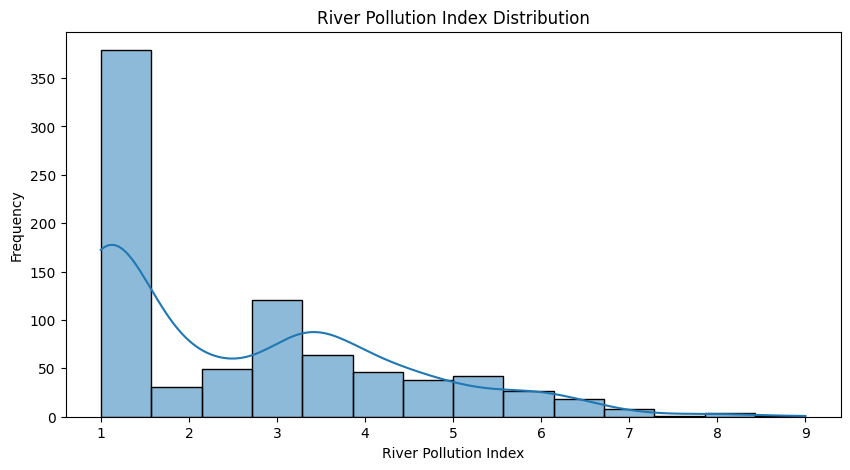

FEATURE CORRELATION WITH RPI
Dissolved Oxygen              -0.703512
Dissolved Oxygen Saturation   -0.692461
Nitrite-Nitrogen               0.672335
NH3-N                          0.661406
Total Organic Carbon           0.658650
Biochemical Oxygen Demand      0.544628
Total-Phosphate                0.518257
Arsenic                        0.477214
Zinc                           0.374890
Nitrate-Nitrogen               0.369658
Copper                         0.342150
Manganese                      0.333550
Nickel                         0.298431
Chemical Oxygen Demand         0.286995
Conductivity                   0.200738
pH                            -0.179743
Coliform Group                 0.157518
Suspended Solid                0.134927
Lead                           0.102375
Water Temperature              0.087561
Temperature                    0.019948
Silver                         0.013886
Cadmium                             NaN
Hexavalent Chromium                 NaN
Mercury    

In [17]:
# ============================================================
# CELL 17 — EXPLORATORY ANALYSIS
# ============================================================

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    y,
    kde=True
)

plt.title(
    "River Pollution Index Distribution"
)

plt.xlabel("River Pollution Index")
plt.ylabel("Frequency")

plt.show()


# ------------------------------------------------------------
# Feature correlations with target
# ------------------------------------------------------------

correlation_df = pd.concat(
    [
        X,
        y.rename(TARGET)
    ],
    axis=1
)

correlations = (
    correlation_df
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("FEATURE CORRELATION WITH RPI")
print("============================")
print(correlations)

In [18]:
# ============================================================
# CELL 18 — TRAIN / TEST SPLIT + 10-FOLD CROSS VALIDATION
# ============================================================

from sklearn.model_selection import (
    train_test_split,
    KFold
)

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("TRAIN / TEST SPLIT")
print("==================")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining shape:", X_train.shape)
print("Testing shape :", X_test.shape)


# ------------------------------------------------------------
# 10-fold CV
# ------------------------------------------------------------

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("\n10-fold cross-validation configured.")

TRAIN / TEST SPLIT
Training samples: 663
Testing samples : 166

Training shape: (663, 26)
Testing shape : (166, 26)

10-fold cross-validation configured.


In [19]:
# ============================================================
# CELL 19 — INITIAL MODELS
# ============================================================

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor


models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        objective="reg:squarederror"
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "CatBoost": CatBoostRegressor(
        iterations=200,
        depth=5,
        learning_rate=0.05,
        random_seed=RANDOM_STATE,
        verbose=False
    )
}

print(
    "Models:",
    list(models.keys())
)

Models: ['Random Forest', 'XGBoost', 'Gradient Boosting', 'CatBoost']


In [20]:
# ============================================================
# CELL 20 — INITIAL MODEL TRAINING + 10-FOLD CV
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            model
        )
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,

        "R2": scores[
            "test_R2"
        ].mean(),

        "RMSE": -scores[
            "test_RMSE"
        ].mean(),

        "MAE": -scores[
            "test_MAE"
        ].mean()
    })


cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df = (
    cv_results_df
    .sort_values(
        "R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("INITIAL 10-FOLD CV RESULTS")
print("===========================")

display(cv_results_df)

INITIAL 10-FOLD CV RESULTS


,Model,R2,RMSE,MAE
0,Gradient Boosting,0.985604,0.197615,0.111980
1,XGBoost,0.981419,0.225248,0.118649
2,CatBoost,0.975705,0.257723,0.157439
3,Random Forest,0.958202,0.341638,0.187761


In [21]:
# ============================================================
# CELL 21 — OVERFITTING / UNDERFITTING CHECK
# ============================================================

fit_results = []

for name, model in models.items():

    pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    train_pred = pipeline.predict(
        X_train
    )

    training_r2 = r2_score(
        y_train,
        train_pred
    )

    cv_r2 = cv_results_df.loc[
        cv_results_df["Model"] == name,
        "R2"
    ].iloc[0]

    gap = training_r2 - cv_r2

    fit_results.append({
        "Model": name,
        "Training R2": training_r2,
        "CV R2": cv_r2,
        "Generalization Gap": gap
    })


fit_df = pd.DataFrame(
    fit_results
).sort_values(
    "CV R2",
    ascending=False
)

print("OVERFITTING / UNDERFITTING ANALYSIS")
print("===================================")

display(fit_df)

OVERFITTING / UNDERFITTING ANALYSIS


,Model,Training R2,CV R2,Generalization Gap
2,Gradient Boosting,0.997981,0.985604,0.012377
1,XGBoost,0.998965,0.981419,0.017546
3,CatBoost,0.992877,0.975705,0.017173
0,Random Forest,0.994733,0.958202,0.036531


In [22]:
# ============================================================
# CELL 22 — CORRECTED MODELS
# ============================================================

corrected_models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        objective="reg:squarederror"
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        depth=4,
        learning_rate=0.03,
        l2_leaf_reg=5,
        random_seed=RANDOM_STATE,
        verbose=False
    )
}

print(
    "Corrected models prepared."
)

Corrected models prepared.


In [23]:
# ============================================================
# CELL 23 — CORRECTED MODEL CV
# ============================================================

corrected_results = []

for name, model in corrected_models.items():

    pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            model
        )
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    corrected_results.append({

        "Model": name,

        "R2": scores[
            "test_R2"
        ].mean(),

        "RMSE": -scores[
            "test_RMSE"
        ].mean(),

        "MAE": -scores[
            "test_MAE"
        ].mean()
    })


corrected_results_df = pd.DataFrame(
    corrected_results
).sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)


print("CORRECTED MODEL RESULTS")
print("=======================")

display(corrected_results_df)

CORRECTED MODEL RESULTS


,Model,R2,RMSE,MAE
0,XGBoost,0.984222,0.208047,0.125270
1,Gradient Boosting,0.978919,0.237172,0.144986
2,CatBoost,0.976147,0.255201,0.163709
3,Random Forest,0.956510,0.348089,0.195131


In [30]:
# ============================================
# CELL 24: SELECT AND TRAIN FINAL XGBOOST
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

best_model_name = "XGBoost"

print("Selected final model:", best_model_name)

# Create the final XGBoost pipeline
final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1,
        random_state=42,
        objective="reg:squarederror"
    ))
])

# Train on training data
final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Selected final model: XGBoost
Final model trained successfully.


In [31]:
# ============================================
# CELL 25: FINAL TEST EVALUATION
# ============================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predict on completely unseen test data
y_test_pred = final_model.predict(X_test)

# Calculate final metrics
final_r2 = r2_score(y_test, y_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
final_mae = mean_absolute_error(y_test, y_test_pred)

print("FINAL TEST RESULTS")
print("==================")
print(f"Model : {best_model_name}")
print(f"R²    : {final_r2:.6f}")
print(f"RMSE  : {final_rmse:.6f}")
print(f"MAE   : {final_mae:.6f}")

FINAL TEST RESULTS
Model : XGBoost
R²    : 0.986093
RMSE  : 0.195627
MAE   : 0.111723


RESIDUAL ANALYSIS
Mean residual : 0.003490
Std residual  : 0.196188
Minimum       : -0.741783
Maximum       : 1.139312


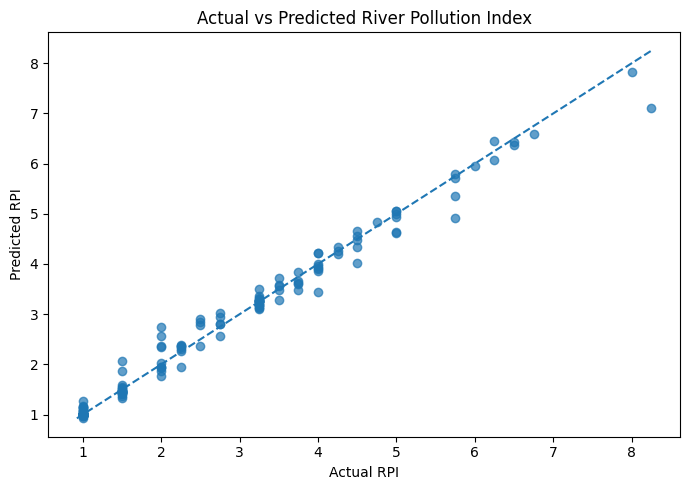

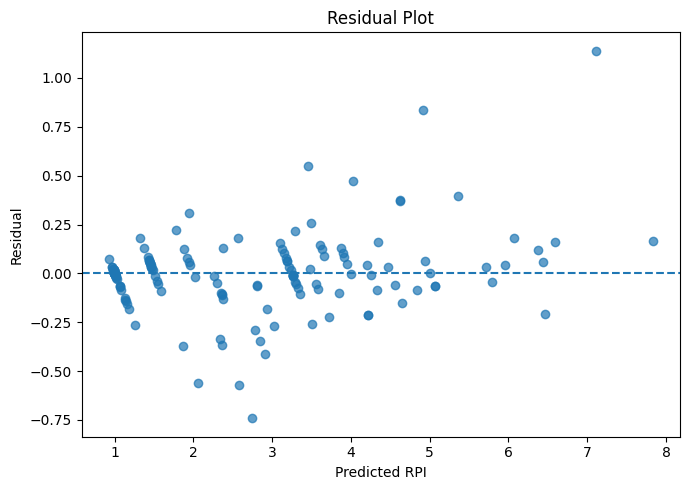

In [32]:
# ============================================
# CELL 26: RESIDUAL ANALYSIS
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals = y_test - y_test_pred

print("RESIDUAL ANALYSIS")
print("=================")
print(f"Mean residual : {residuals.mean():.6f}")
print(f"Std residual  : {residuals.std():.6f}")
print(f"Minimum       : {residuals.min():.6f}")
print(f"Maximum       : {residuals.max():.6f}")


# --------------------------------------------
# Actual vs Predicted
# --------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_test_pred, alpha=0.7)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual RPI")
plt.ylabel("Predicted RPI")
plt.title("Actual vs Predicted River Pollution Index")

plt.tight_layout()
plt.show()


# --------------------------------------------
# Residual Plot
# --------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(y_test_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted RPI")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

TOP 15 FEATURES


,Feature,Importance
13,NH3-N,0.442329
3,Chemical Oxygen Demand,0.159419
19,Suspended Solid,0.116722
8,Dissolved Oxygen Saturation,0.091405
1,Biochemical Oxygen Demand,0.076985
7,Dissolved Oxygen,0.063736
5,Conductivity,0.014538
4,Coliform Group,0.007804
11,Manganese,0.007611
22,Total-Phosphate,0.003463


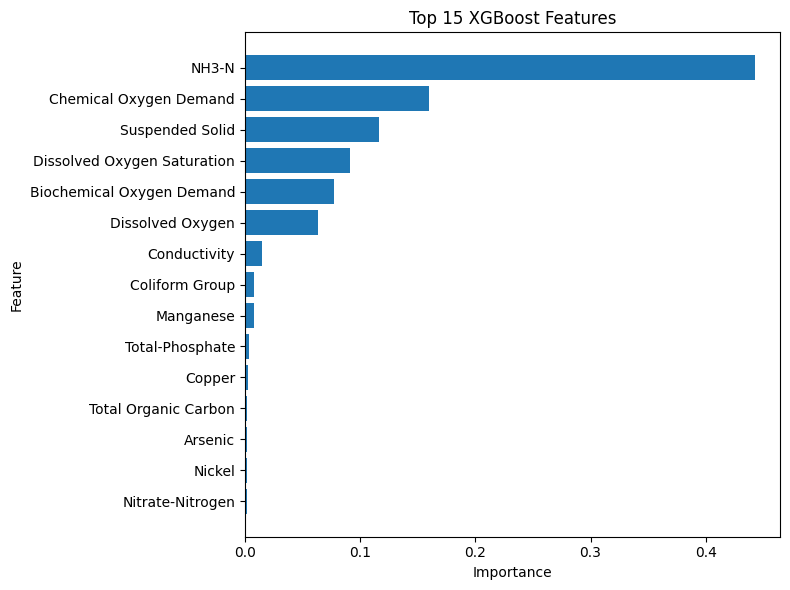

In [33]:
# ============================================
# CELL 27: FEATURE IMPORTANCE
# ============================================

# Get the trained XGBoost model from the pipeline
trained_model = final_model.named_steps["model"]

# Get feature importance
importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": trained_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("TOP 15 FEATURES")
print("================")

display(importance_df.head(15))


# Plot top 15 features
top_features = importance_df.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")

plt.tight_layout()
plt.show()

In [34]:
# ============================================
# CELL 28: SHAP ANALYSIS
# ============================================

import shap

# Get preprocessing step from pipeline
preprocessor = final_model.named_steps["imputer"]

# Transform test data using the same imputer
X_test_processed = preprocessor.transform(X_test)

# Convert to DataFrame with feature names
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_columns,
    index=X_test.index
)

# Create SHAP Tree Explainer
explainer = shap.TreeExplainer(trained_model)

# Calculate SHAP values
shap_values = explainer.shap_values(
    X_test_processed_df
)

print("SHAP analysis completed.")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP analysis completed.
SHAP values shape: (166, 26)


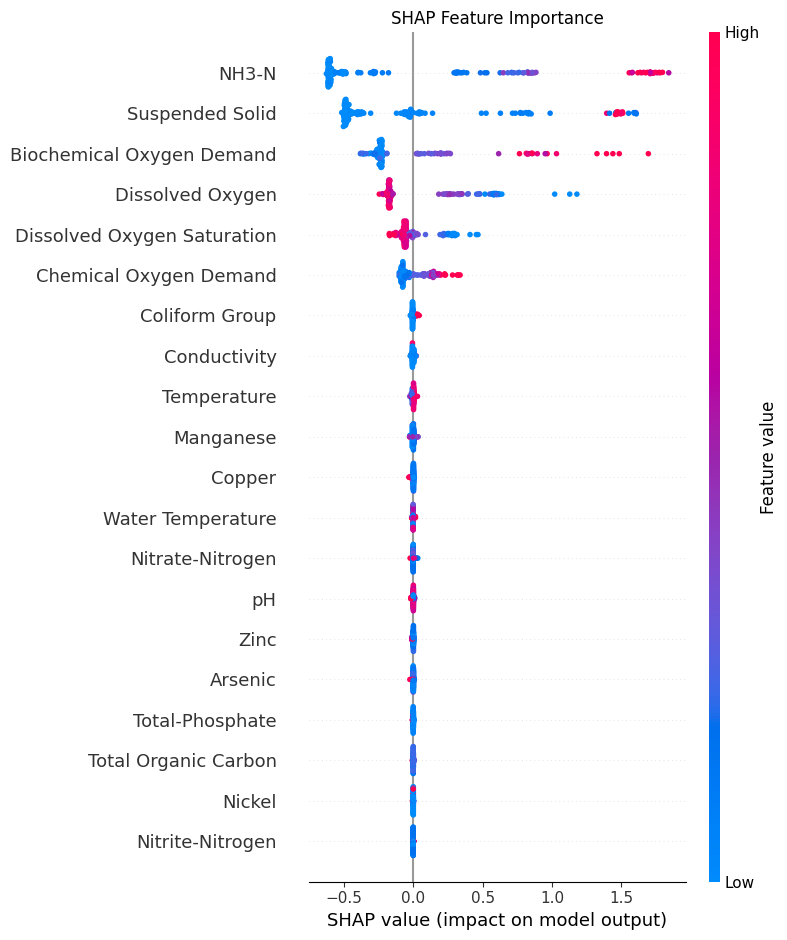

In [35]:
# ============================================
# CELL 29: SHAP SUMMARY PLOT
# ============================================

plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_values,
    X_test_processed_df,
    show=False
)

plt.title("SHAP Feature Importance")

plt.tight_layout()
plt.show()

In [36]:
# ============================================
# CELL 30: CREATE STANDARDIZED PREDICTION OUTPUT
# ============================================

# Get original rows corresponding to the test set
prediction_output = quality_df.loc[X_test.index].copy()

# Add prediction information
prediction_output["observed"] = y_test.values
prediction_output["predicted"] = y_test_pred
prediction_output["residual"] = residuals.values
prediction_output["model_version"] = best_model_name

# Standardize column names for team integration
prediction_output = prediction_output.rename(columns={
    "siteid": "site_id",
    "twd97lat": "lat",
    "twd97lon": "lon",
    "sampledate": "timestamp"
})

# Select important integration columns
integration_columns = [
    "site_id",
    "lat",
    "lon",
    "timestamp",
    "observed",
    "predicted",
    "residual",
    "model_version"
]

print("STANDARDIZED PREDICTION OUTPUT")
print("==============================")

display(
    prediction_output[integration_columns].head()
)

print("\nOutput shape:", prediction_output.shape)

STANDARDIZED PREDICTION OUTPUT


,site_id,lat,lon,timestamp,observed,predicted,residual,model_version
608,1252,23.931694,121.538586,2025-10-01 07:48:23,1.0,1.137137,-0.137137,XGBoost
457,1191,22.875694,120.362167,2021-01-06 11:35:00,4.5,4.469664,0.030336,XGBoost
290,1113,24.275056,120.773972,2026-07-27 14:00:00,1.5,1.590462,-0.090462,XGBoost
558,1234,24.632364,121.831560,2025-10-02 08:05:56,1.0,0.993162,0.006838,XGBoost
168,1066,24.939901,121.002716,2025-10-01 13:36:19,2.0,2.741783,-0.741783,XGBoost



Output shape: (166, 41)


In [37]:
# ============================================
# CELL 31: SAVE PREDICTIONS
# ============================================

import os

os.makedirs("outputs", exist_ok=True)

prediction_file = "outputs/predictions.csv"

prediction_output.to_csv(
    prediction_file,
    index=False
)

print("Predictions saved successfully.")
print(prediction_file)

Predictions saved successfully.
outputs/predictions.csv


In [38]:
# ============================================
# CELL 32: SAVE FINAL MODEL
# ============================================

import joblib

os.makedirs("models", exist_ok=True)

model_file = "models/final_model.pkl"

joblib.dump(
    final_model,
    model_file
)

print("Final model saved successfully.")
print(model_file)

Final model saved successfully.
models/final_model.pkl


In [39]:
# ============================================
# CELL 33: SAVE FEATURES + METRICS
# ============================================

import json

# Save feature columns
with open("models/feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=4)


# Save model metrics
model_metrics = {
    "model": best_model_name,

    "cv_r2": 0.984222,
    "cv_rmse": 0.208047,
    "cv_mae": 0.125270,

    "test_r2": float(final_r2),
    "test_rmse": float(final_rmse),
    "test_mae": float(final_mae)
}

with open("models/model_metrics.json", "w") as f:
    json.dump(model_metrics, f, indent=4)

print("Model metadata saved successfully.")

print("\nFiles:")
print("models/feature_columns.json")
print("models/model_metrics.json")

Model metadata saved successfully.

Files:
models/feature_columns.json
models/model_metrics.json


In [40]:
# ============================================
# CELL 34: CREATE predict.py
# ============================================

predict_code = '''
import joblib
import pandas as pd


def load_model(model_path="models/final_model.pkl"):
    """Load the trained model."""
    return joblib.load(model_path)


def predict(data, model_path="models/final_model.pkl"):
    """Generate RPI predictions for new data."""

    model = load_model(model_path)

    predictions = model.predict(data)

    return predictions


def predict_dataframe(
    data,
    model_path="models/final_model.pkl"
):
    """Return input data with predicted RPI."""

    model = load_model(model_path)

    result = data.copy()

    result["predicted"] = model.predict(data)

    return result
'''

os.makedirs("src/models", exist_ok=True)

with open("src/models/predict.py", "w") as f:
    f.write(predict_code)

print("Created successfully:")
print("src/models/predict.py")

Created successfully:
src/models/predict.py


In [41]:
# ============================================
# CELL 35: FINAL VERIFICATION
# ============================================

print("==========================================")
print("PREDICTION MODEL PIPELINE COMPLETE")
print("==========================================")

print("\nFinal model:")
print(best_model_name)

print("\nFinal test performance:")
print(f"R²   : {final_r2:.6f}")
print(f"RMSE : {final_rmse:.6f}")
print(f"MAE  : {final_mae:.6f}")

print("\nGenerated files:")

files_to_check = [
    "outputs/predictions.csv",
    "models/final_model.pkl",
    "models/feature_columns.json",
    "models/model_metrics.json",
    "src/models/predict.py"
]

for path in files_to_check:
    print("✓", path)

print("\nPrediction output:")
print(prediction_output[integration_columns].shape)

print("\nReady for integration:")
print("Member 2 → Spatial + Temporal Analysis")
print("Member 3 → Anomaly + Uncertainty Analysis")

PREDICTION MODEL PIPELINE COMPLETE

Final model:
XGBoost

Final test performance:
R²   : 0.986093
RMSE : 0.195627
MAE  : 0.111723

Generated files:
✓ outputs/predictions.csv
✓ models/final_model.pkl
✓ models/feature_columns.json
✓ models/model_metrics.json
✓ src/models/predict.py

Prediction output:
(166, 8)

Ready for integration:
Member 2 → Spatial + Temporal Analysis
Member 3 → Anomaly + Uncertainty Analysis
